# Notebook 7: Validation Report
**PURPOSE:** Comprehensive validation before deployment. Generate all charts. Test edge cases.

In [1]:
import os
project_root = r"C:\Users\srich\OneDrive\Desktop\prediction-model"
os.chdir(project_root)
print(f"✅ Working directory: {os.getcwd()}")

✅ Working directory: C:\Users\srich\OneDrive\Desktop\prediction-model


In [2]:
import pandas as pd
import numpy as np
import pickle, json, os, warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
plt.style.use('dark_background')

from sklearn.metrics import accuracy_score, brier_score_loss, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
from sklearn.calibration import calibration_curve

print('Libraries loaded ✅')

Libraries loaded ✅


In [3]:
test_df = pd.read_csv('data/processed/test_data.csv')
with open('model/feature_names.json') as f:
    feature_cols = json.load(f)
with open('model/ensemble_config.json') as f:
    config = json.load(f)
with open('model/model_metrics.json') as f:
    metrics = json.load(f)

X_test = test_df[feature_cols]
y_test = test_df['result']

with open('model/ensemble_model.pkl', 'rb') as f:
    ensemble = pickle.load(f)

models = ensemble['models']
weights = ensemble['weights']
names = ensemble['model_names']

probs = [m.predict_proba(X_test)[:, 1] for m in models.values()]
total_w = sum(weights)
y_prob = sum(w * p for w, p in zip(weights, probs)) / total_w

print('Model loaded ✅')
print(f'Test samples: {len(y_test):,}')

Model loaded ✅
Test samples: 19,410


## 7.1 Accuracy by Match Phase

=== ACCURACY BY PHASE ===

Powerplay (Overs 1-6): Accuracy=72.4%, Brier=0.1827, Samples=2,617
Middle Overs (7-15): Accuracy=79.4%, Brier=0.1469, Samples=11,609
Death Overs (16-20): Accuracy=86.9%, Brier=0.0883, Samples=5,184


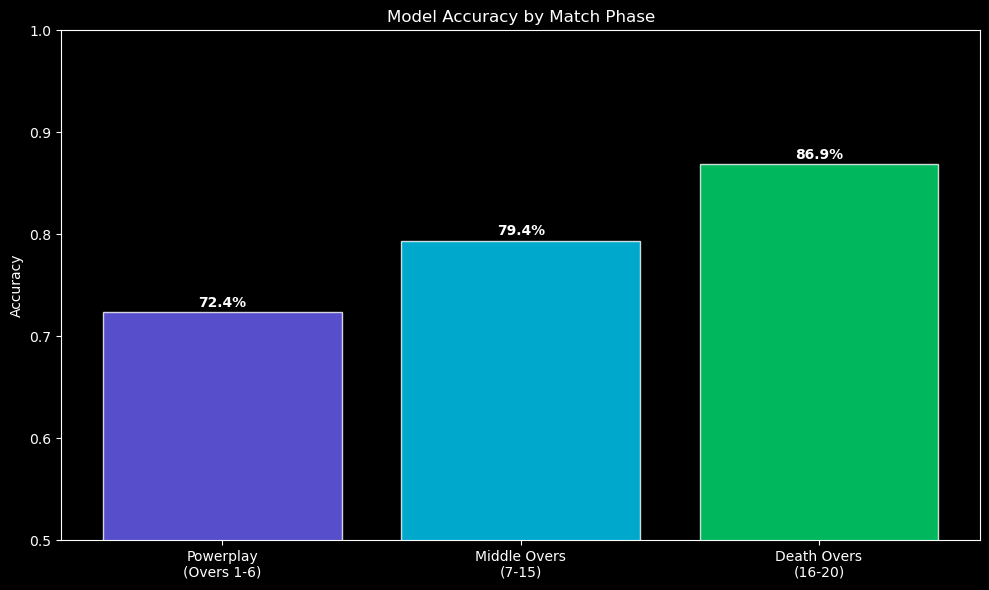

✅ Saved: charts/accuracy_by_phase.png


In [4]:
phases = {
    'Powerplay\n(Overs 1-6)': test_df['over_number'] <= 6,
    'Middle Overs\n(7-15)': (test_df['over_number'] > 6) & (test_df['over_number'] <= 15),
    'Death Overs\n(16-20)': test_df['over_number'] > 15
}

phase_results = {}
print('=== ACCURACY BY PHASE ===\n')
for phase, mask in phases.items():
    if mask.sum() == 0: continue
    y_phase = y_test[mask]
    p_phase = y_prob[mask]
    acc = accuracy_score(y_phase, (p_phase > 0.5).astype(int))
    brier = brier_score_loss(y_phase, p_phase)
    phase_results[phase] = {'accuracy': acc, 'brier': brier, 'count': int(mask.sum())}
    clean = phase.replace('\n', ' ')
    print(f'{clean}: Accuracy={acc:.1%}, Brier={brier:.4f}, Samples={mask.sum():,}')

fig, ax = plt.subplots(figsize=(10, 6))
phase_names = list(phase_results.keys())
accs = [phase_results[p]['accuracy'] for p in phase_names]
colors = ['#6C63FF', '#00D4FF', '#00E676']
bars = ax.bar(phase_names, accs, color=colors, alpha=0.8, edgecolor='white')
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy by Match Phase')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{acc:.1%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('charts/accuracy_by_phase.png', dpi=150)
plt.show()
print('✅ Saved: charts/accuracy_by_phase.png')

## 7.2 Confusion Matrix

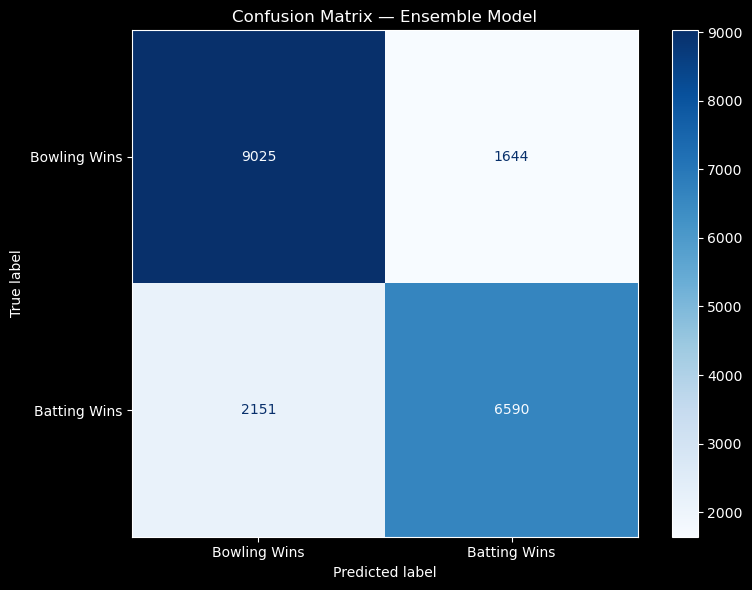

✅ Saved: charts/confusion_matrix.png


In [5]:
y_pred = (y_prob > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(cm, display_labels=['Bowling Wins', 'Batting Wins'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix — Ensemble Model')
plt.tight_layout()
plt.savefig('charts/confusion_matrix.png', dpi=150)
plt.show()
print('✅ Saved: charts/confusion_matrix.png')

## 7.3 ROC Curves

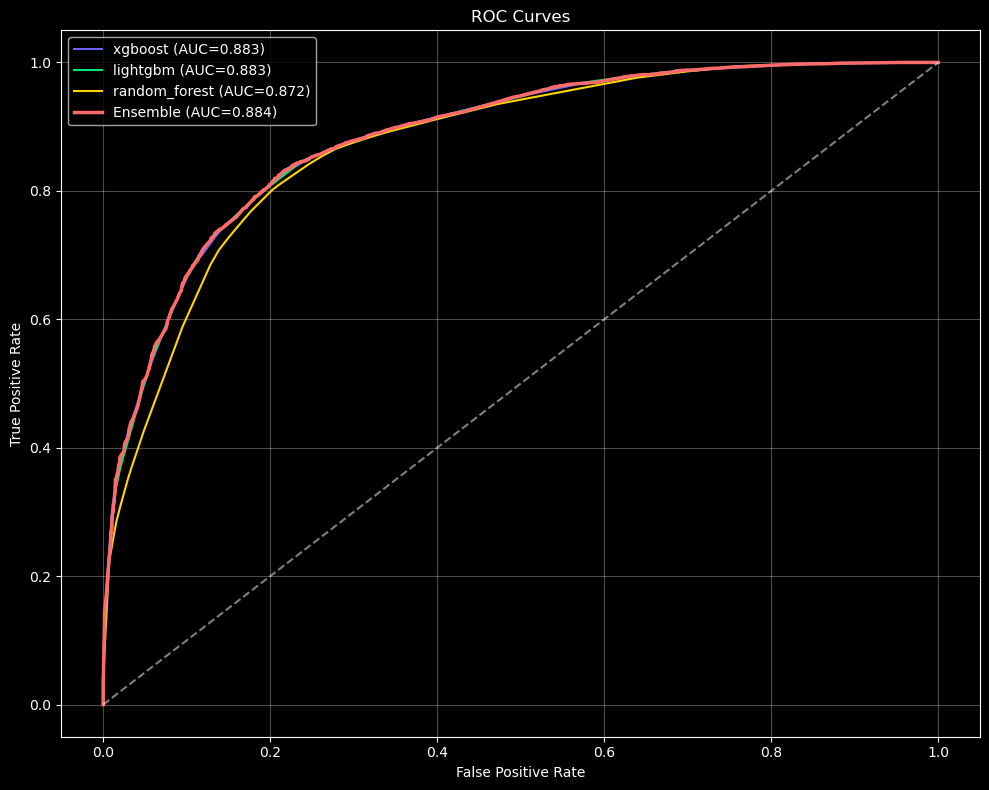

✅ Saved: charts/roc_curves.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#6C63FF', '#00E676', '#FFD700']

for (name, model), color in zip(models.items(), colors):
    prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, color=color, label=f'{name} (AUC={auc:.3f})')

# Ensemble
fpr_e, tpr_e, _ = roc_curve(y_test, y_prob)
auc_e = roc_auc_score(y_test, y_prob)
ax.plot(fpr_e, tpr_e, color='#FF6B6B', linewidth=2.5, label=f'Ensemble (AUC={auc_e:.3f})')
ax.plot([0, 1], [0, 1], 'w--', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts/roc_curves.png', dpi=150)
plt.show()
print('✅ Saved: charts/roc_curves.png')

## 7.4 Feature Importance

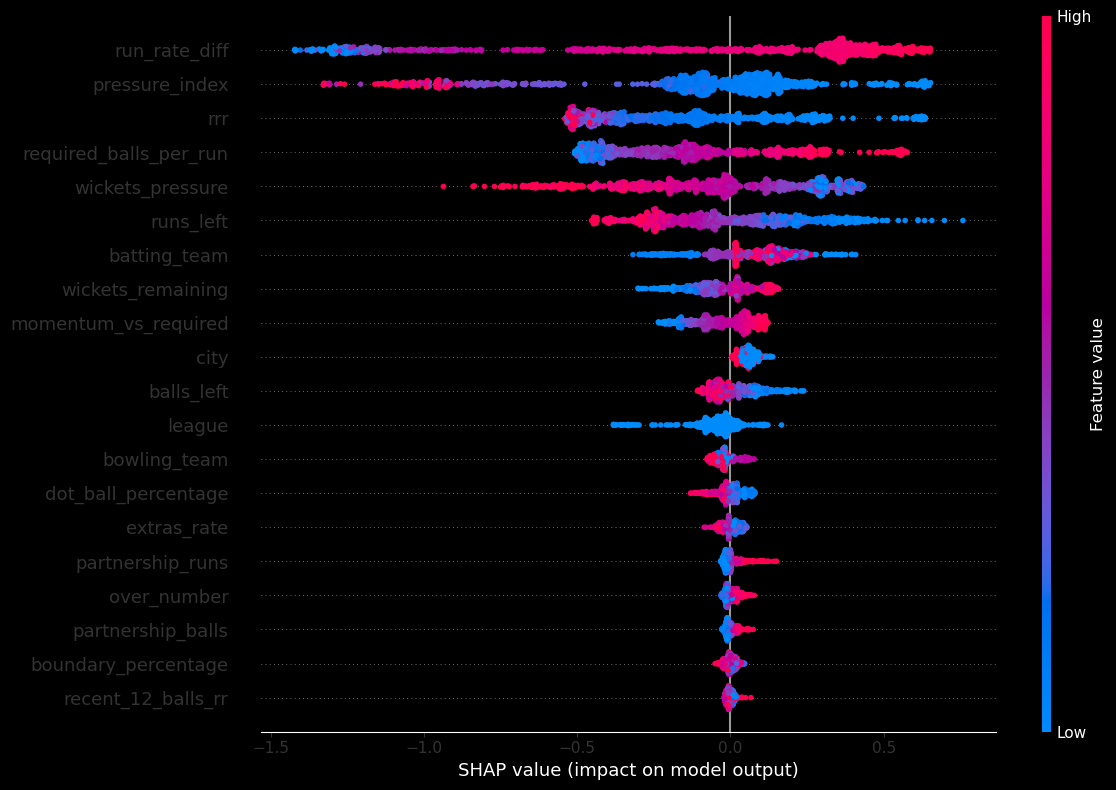

✅ Saved: charts/feature_importance.png


In [7]:
try:
    import shap
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'shap', '--quiet'], check=True)
    import shap

# Get base model from first calibrated model
first_model = list(models.values())[0]
base_model = first_model
if hasattr(first_model, 'calibrated_classifiers_'):
    base_model = first_model.calibrated_classifiers_[0].estimator

try:
    explainer = shap.TreeExplainer(base_model)
    sample_size = min(1000, len(X_test))
    X_sample = X_test.iloc[:sample_size]
    shap_values = explainer.shap_values(X_sample)
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_sample, feature_names=feature_cols, show=False, plot_size=(12, 8))
    plt.tight_layout()
    plt.savefig('charts/feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Saved: charts/feature_importance.png')
except Exception as e:
    print(f'SHAP error: {e}')
    if hasattr(base_model, 'feature_importances_'):
        imp = pd.Series(base_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
        fig, ax = plt.subplots(figsize=(10, 12))
        imp.tail(20).plot.barh(ax=ax, color='#6C63FF')
        ax.set_title('Feature Importance (Top 20)')
        plt.tight_layout()
        plt.savefig('charts/feature_importance.png', dpi=150)
        plt.show()
        print('✅ Saved: charts/feature_importance.png (fallback)')

## 7.5 Edge Case Testing

In [8]:
with open('model/label_encoders.pkl', 'rb') as f:
    encoders = pickle.load(f)

def encode_val(val, key):
    le = encoders[key]
    if val in le.classes_:
        return le.transform([val])[0]
    return le.transform([le.classes_[0]])[0]

def predict_scenario(scenario_dict, scenario_name):
    row = {}
    for feat in feature_cols:
        row[feat] = scenario_dict.get(feat, 0)
    for col in ['batting_team', 'bowling_team', 'city', 'league']:
        if col in row and isinstance(row[col], str):
            row[col] = encode_val(row[col], col)
    df_row = pd.DataFrame([row])
    probs_list = [m.predict_proba(df_row)[0][1] for m in models.values()]
    total = sum(weights)
    prob = sum(w * p for w, p in zip(weights, probs_list)) / total
    prob = max(0.05, min(0.95, prob))
    print(f'\n{"─"*45}')
    print(f'Scenario: {scenario_name}')
    print(f'  → Chasing team win: {prob:.1%}')
    print(f'  → Defending team:   {1-prob:.1%}')
    return prob

scenarios = [
    ({'runs_left': 125, 'balls_left': 36, 'wickets_remaining': 2, 'crr': 5.83, 'rrr': 20.83, 'run_rate_diff': -15.0, 'over_number': 14, 'is_powerplay': 0, 'is_middle_overs': 1, 'is_death_overs': 0, 'pressure_index': 3.57, 'batting_team': 'Chennai Super Kings', 'bowling_team': 'Mumbai Indians', 'city': 'Chennai', 'league': 'IPL', 'total_extras': 4, 'extras_rate': 0.3, 'boundary_percentage': 0.2, 'dot_ball_percentage': 0.4, 'partnership_runs': 15, 'recent_12_balls_rr': 4.5, 'wides_this_innings': 2, 'extra_balls_gained': 3, 'momentum_vs_required': -16.0, 'required_balls_per_run': 0.29, 'wickets_pressure': 0.57, 'last_3_overs_avg': 5.0, 'partnership_balls': 10}, 'Near Impossible Chase (125 off 36, 8 down)'),
    ({'runs_left': 15, 'balls_left': 30, 'wickets_remaining': 9, 'crr': 8.75, 'rrr': 3.0, 'run_rate_diff': 5.75, 'over_number': 15, 'is_powerplay': 0, 'is_middle_overs': 0, 'is_death_overs': 1, 'pressure_index': 0.34, 'batting_team': 'Mumbai Indians', 'bowling_team': 'Chennai Super Kings', 'city': 'Mumbai', 'league': 'IPL', 'total_extras': 6, 'extras_rate': 0.4, 'boundary_percentage': 0.35, 'dot_ball_percentage': 0.2, 'partnership_runs': 45, 'recent_12_balls_rr': 9.0, 'wides_this_innings': 3, 'extra_balls_gained': 4, 'momentum_vs_required': 6.0, 'required_balls_per_run': 2.0, 'wickets_pressure': 0.07, 'last_3_overs_avg': 9.5, 'partnership_balls': 25}, 'Easy Chase (15 off 30, 9 wickets)'),
    ({'runs_left': 13, 'balls_left': 6, 'wickets_remaining': 5, 'crr': 8.5, 'rrr': 13.0, 'run_rate_diff': -4.5, 'over_number': 19, 'is_powerplay': 0, 'is_middle_overs': 0, 'is_death_overs': 1, 'pressure_index': 1.53, 'batting_team': 'Royal Challengers Bengaluru', 'bowling_team': 'Kolkata Knight Riders', 'city': 'Bengaluru', 'league': 'IPL', 'total_extras': 8, 'extras_rate': 0.42, 'boundary_percentage': 0.3, 'dot_ball_percentage': 0.35, 'partnership_runs': 22, 'recent_12_balls_rr': 7.0, 'wides_this_innings': 5, 'extra_balls_gained': 6, 'momentum_vs_required': -6.0, 'required_balls_per_run': 0.46, 'wickets_pressure': 0.75, 'last_3_overs_avg': 7.5, 'partnership_balls': 15}, 'Thriller Last Over (13 off 6)'),
    ({'runs_left': 67, 'balls_left': 48, 'wickets_remaining': 7, 'crr': 7.0, 'rrr': 8.375, 'run_rate_diff': -1.375, 'over_number': 12, 'is_powerplay': 0, 'is_middle_overs': 1, 'is_death_overs': 0, 'pressure_index': 1.2, 'batting_team': 'Rajasthan Royals', 'bowling_team': 'Sunrisers Hyderabad', 'city': 'Jaipur', 'league': 'IPL', 'total_extras': 5, 'extras_rate': 0.42, 'boundary_percentage': 0.28, 'dot_ball_percentage': 0.32, 'partnership_runs': 30, 'recent_12_balls_rr': 6.5, 'wides_this_innings': 3, 'extra_balls_gained': 4, 'momentum_vs_required': -1.875, 'required_balls_per_run': 0.72, 'wickets_pressure': 0.25, 'last_3_overs_avg': 7.0, 'partnership_balls': 20}, 'Classic Pressure (67 off 48)'),
    ({'runs_left': 67, 'balls_left': 48, 'wickets_remaining': 7, 'crr': 7.0, 'rrr': 8.375, 'run_rate_diff': -1.375, 'over_number': 12, 'is_powerplay': 0, 'is_middle_overs': 1, 'is_death_overs': 0, 'pressure_index': 1.2, 'batting_team': 'Rajasthan Royals', 'bowling_team': 'Sunrisers Hyderabad', 'city': 'Jaipur', 'league': 'IPL', 'total_extras': 15, 'extras_rate': 1.25, 'boundary_percentage': 0.28, 'dot_ball_percentage': 0.32, 'partnership_runs': 30, 'recent_12_balls_rr': 6.5, 'wides_this_innings': 10, 'extra_balls_gained': 12, 'momentum_vs_required': -1.875, 'required_balls_per_run': 0.72, 'wickets_pressure': 0.25, 'last_3_overs_avg': 7.0, 'partnership_balls': 20}, 'Same + High Extras (extras factor test)'),
    ({'runs_left': 13, 'balls_left': 7, 'wickets_remaining': 5, 'crr': 8.3, 'rrr': 11.14, 'run_rate_diff': -2.84, 'over_number': 19, 'is_powerplay': 0, 'is_middle_overs': 0, 'is_death_overs': 1, 'pressure_index': 1.34, 'batting_team': 'Punjab Kings', 'bowling_team': 'Delhi Capitals', 'city': 'Delhi', 'league': 'IPL', 'total_extras': 8, 'extras_rate': 0.42, 'boundary_percentage': 0.3, 'dot_ball_percentage': 0.35, 'partnership_runs': 22, 'recent_12_balls_rr': 7.0, 'wides_this_innings': 5, 'extra_balls_gained': 7, 'momentum_vs_required': -4.14, 'required_balls_per_run': 0.54, 'wickets_pressure': 0.75, 'last_3_overs_avg': 7.5, 'partnership_balls': 15}, 'Free Hit Death Over (7 balls due to no ball)')
]

print('=== EDGE CASE TESTING ===')
results_edge = []
for scenario, name in scenarios:
    prob = predict_scenario(scenario, name)
    results_edge.append({'scenario': name, 'prob': prob})

print('\n\n=== SUMMARY ===')
for r in results_edge:
    print(f'{r["scenario"][:40]:40s} → {r["prob"]:.1%}')

=== EDGE CASE TESTING ===

─────────────────────────────────────────────
Scenario: Near Impossible Chase (125 off 36, 8 down)
  → Chasing team win: 5.0%
  → Defending team:   95.0%

─────────────────────────────────────────────
Scenario: Easy Chase (15 off 30, 9 wickets)
  → Chasing team win: 95.0%
  → Defending team:   5.0%

─────────────────────────────────────────────
Scenario: Thriller Last Over (13 off 6)
  → Chasing team win: 21.1%
  → Defending team:   78.9%

─────────────────────────────────────────────
Scenario: Classic Pressure (67 off 48)
  → Chasing team win: 75.7%
  → Defending team:   24.3%

─────────────────────────────────────────────
Scenario: Same + High Extras (extras factor test)
  → Chasing team win: 75.7%
  → Defending team:   24.3%

─────────────────────────────────────────────
Scenario: Free Hit Death Over (7 balls due to no ball)
  → Chasing team win: 22.9%
  → Defending team:   77.1%


=== SUMMARY ===
Near Impossible Chase (125 off 36, 8 dow → 5.0%
Easy Chase 

## 7.6 Brier Score by Over

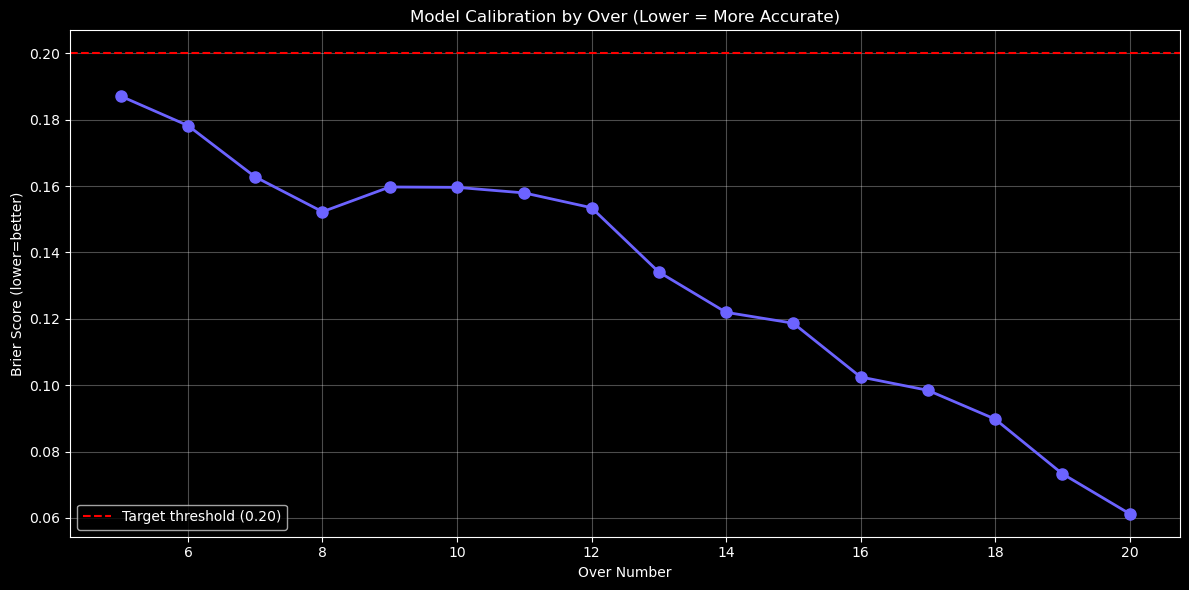

✅ Saved: charts/brier_by_over.png


In [9]:
brier_by_over = []
for over in range(5, 21):
    mask = test_df['over_number'] == over
    if mask.sum() < 50: continue
    brier = brier_score_loss(y_test[mask], y_prob[mask])
    brier_by_over.append({'over': over, 'brier': brier, 'count': int(mask.sum())})

brier_df = pd.DataFrame(brier_by_over)
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(brier_df['over'], brier_df['brier'], marker='o', color='#6C63FF', linewidth=2, markersize=8)
ax.set_xlabel('Over Number')
ax.set_ylabel('Brier Score (lower=better)')
ax.set_title('Model Calibration by Over (Lower = More Accurate)')
ax.axhline(y=0.20, color='red', linestyle='--', label='Target threshold (0.20)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts/brier_by_over.png', dpi=150)
plt.show()
print('✅ Saved: charts/brier_by_over.png')

## 7.7 Speed Benchmark

In [10]:
import time
single_row = X_test.iloc[:1]

# Single prediction
times = []
for _ in range(100):
    start = time.time()
    for m in models.values():
        m.predict_proba(single_row)
    times.append((time.time() - start) * 1000)
avg_single = np.mean(times)

# Batch 1000
batch = X_test.iloc[:1000]
start = time.time()
for m in models.values():
    m.predict_proba(batch)
batch_time = (time.time() - start) * 1000

print('=== SPEED BENCHMARK ===')
print(f'Single prediction: {avg_single:.1f}ms (avg over 100 runs)')
print(f'1000 predictions:  {batch_time:.1f}ms')
print(f'Target: < 500ms per single ✅' if avg_single < 500 else '❌ Too slow!')

=== SPEED BENCHMARK ===
Single prediction: 78.4ms (avg over 100 runs)
1000 predictions:  102.6ms
Target: < 500ms per single ✅


## 7.8 Final Readiness Report

In [11]:
print('\n' + '='*50)
print('  FINAL READINESS REPORT')
print('='*50)

y_pred_final = (y_prob > 0.5).astype(int)
final_accuracy = accuracy_score(y_test, y_pred_final)
final_brier = brier_score_loss(y_test, y_prob)
final_auc = roc_auc_score(y_test, y_prob)

death_mask = test_df['over_number'] > 15
death_acc = accuracy_score(y_test[death_mask], (y_prob[death_mask] > 0.5).astype(int))

checks = {
    'Brier score < 0.20': final_brier < 0.20,
    'Accuracy > 78%': final_accuracy > 0.78,
    'ROC-AUC > 0.82': final_auc > 0.82,
    'Death over accuracy > 82%': death_acc > 0.82,
    'ensemble_model.pkl saved': os.path.exists('model/ensemble_model.pkl'),
    'feature_names.json saved': os.path.exists('model/feature_names.json'),
    'label_encoders.pkl saved': os.path.exists('model/label_encoders.pkl'),
    'model_metrics.json saved': os.path.exists('model/model_metrics.json'),
}

all_passed = True
for check, passed in checks.items():
    status = '✅' if passed else '❌'
    print(f'  {status} {check}')
    if not passed: all_passed = False

print(f'\n{"="*50}')
print(f'  Overall Accuracy: {final_accuracy:.4f} ({final_accuracy*100:.1f}%)')
print(f'  Brier Score:      {final_brier:.4f}')
print(f'  ROC-AUC:          {final_auc:.4f}')
print(f'  Death Over Acc:   {death_acc:.4f}')
print(f'{"="*50}')

if all_passed:
    print('\n  🚀 READY FOR API DEPLOYMENT!')
else:
    print('\n  ⚠️  FIX FAILING CHECKS FIRST')


  FINAL READINESS REPORT
  ✅ Brier score < 0.20
  ✅ Accuracy > 78%
  ✅ ROC-AUC > 0.82
  ✅ Death over accuracy > 82%
  ✅ ensemble_model.pkl saved
  ✅ feature_names.json saved
  ✅ label_encoders.pkl saved
  ✅ model_metrics.json saved

  Overall Accuracy: 0.8045 (80.4%)
  Brier Score:      0.1361
  ROC-AUC:          0.8838
  Death Over Acc:   0.8690

  🚀 READY FOR API DEPLOYMENT!
